In [177]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option('display.max_columns', None)

In [178]:
# reading data from source
train = pd.read_csv(r'C:\Kaggle_Competition\Playground\S6E3-Customer-Churn\data\raw\train.csv')
test = pd.read_csv(r'C:\Kaggle_Competition\Playground\S6E3-Customer-Churn\data\raw\test.csv')
exog = pd.read_csv(r'C:\Kaggle_Competition\Playground\S6E3-Customer-Churn\data\exog\IBM-Telco-Customer-Churn.csv')

In [179]:
# shape of data
print(f'Shape of train: {train.shape}')
print(f'Shape of test: {test.shape}')
print(f'Shape of exog: {exog.shape}')

Shape of train: (594194, 21)
Shape of test: (254655, 20)
Shape of exog: (7043, 21)


In [180]:
# check for nullity
print(f'Total null values in the train: {train.isna().sum().sum()}')
print(f'Total null values in the test: {test.isna().sum().sum()}')
print(f'Total null values in the exog: {exog.isna().sum().sum()}')

Total null values in the train: 0
Total null values in the test: 0
Total null values in the exog: 0


In [181]:
# check for duplicates
print(f'Total duplicates in the train: {train.duplicated().sum()}')
print(f'Total duplicates in the test: {test.duplicated().sum()}')
print(f'Total duplicates in the exog: {exog.duplicated().sum()}')

Total duplicates in the train: 0
Total duplicates in the test: 0
Total duplicates in the exog: 0


In [182]:
cat_cols = [
    'gender',
    'SeniorCitizen',
    'Partner', 
    'Dependents', 
    'PhoneService', 
    'MultipleLines', 
    'InternetService', 
    'OnlineSecurity', 
    'OnlineBackup', 
    'DeviceProtection', 
    'TechSupport', 
    'StreamingTV', 
    'StreamingMovies', 
    'Contract', 
    'PaperlessBilling', 
    'PaymentMethod', 
    #'Churn'
]

num_cols = [
    #'id',  
    'tenure', 
    'MonthlyCharges', 
    'TotalCharges'
]

### Cardinality of categorical features

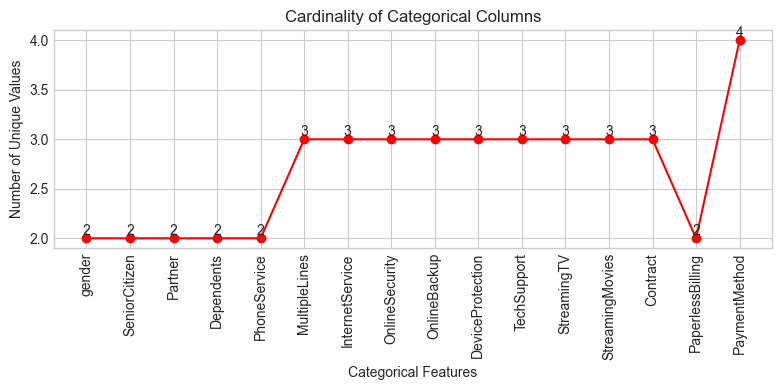

In [183]:
# Cardinality of categorical columns
cardinality = train[cat_cols].nunique()

plt.figure(figsize=(8, 4))
plt.plot(cardinality.index, cardinality.values, marker='o', color='red')

# Add value labels
for i, value in enumerate(cardinality.values):
    plt.text(i, value, str(value), ha='center', va='bottom')

plt.title('Cardinality of Categorical Columns')
plt.xlabel('Categorical Features')
plt.ylabel('Number of Unique Values')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Percentage count plot of train, test and exog

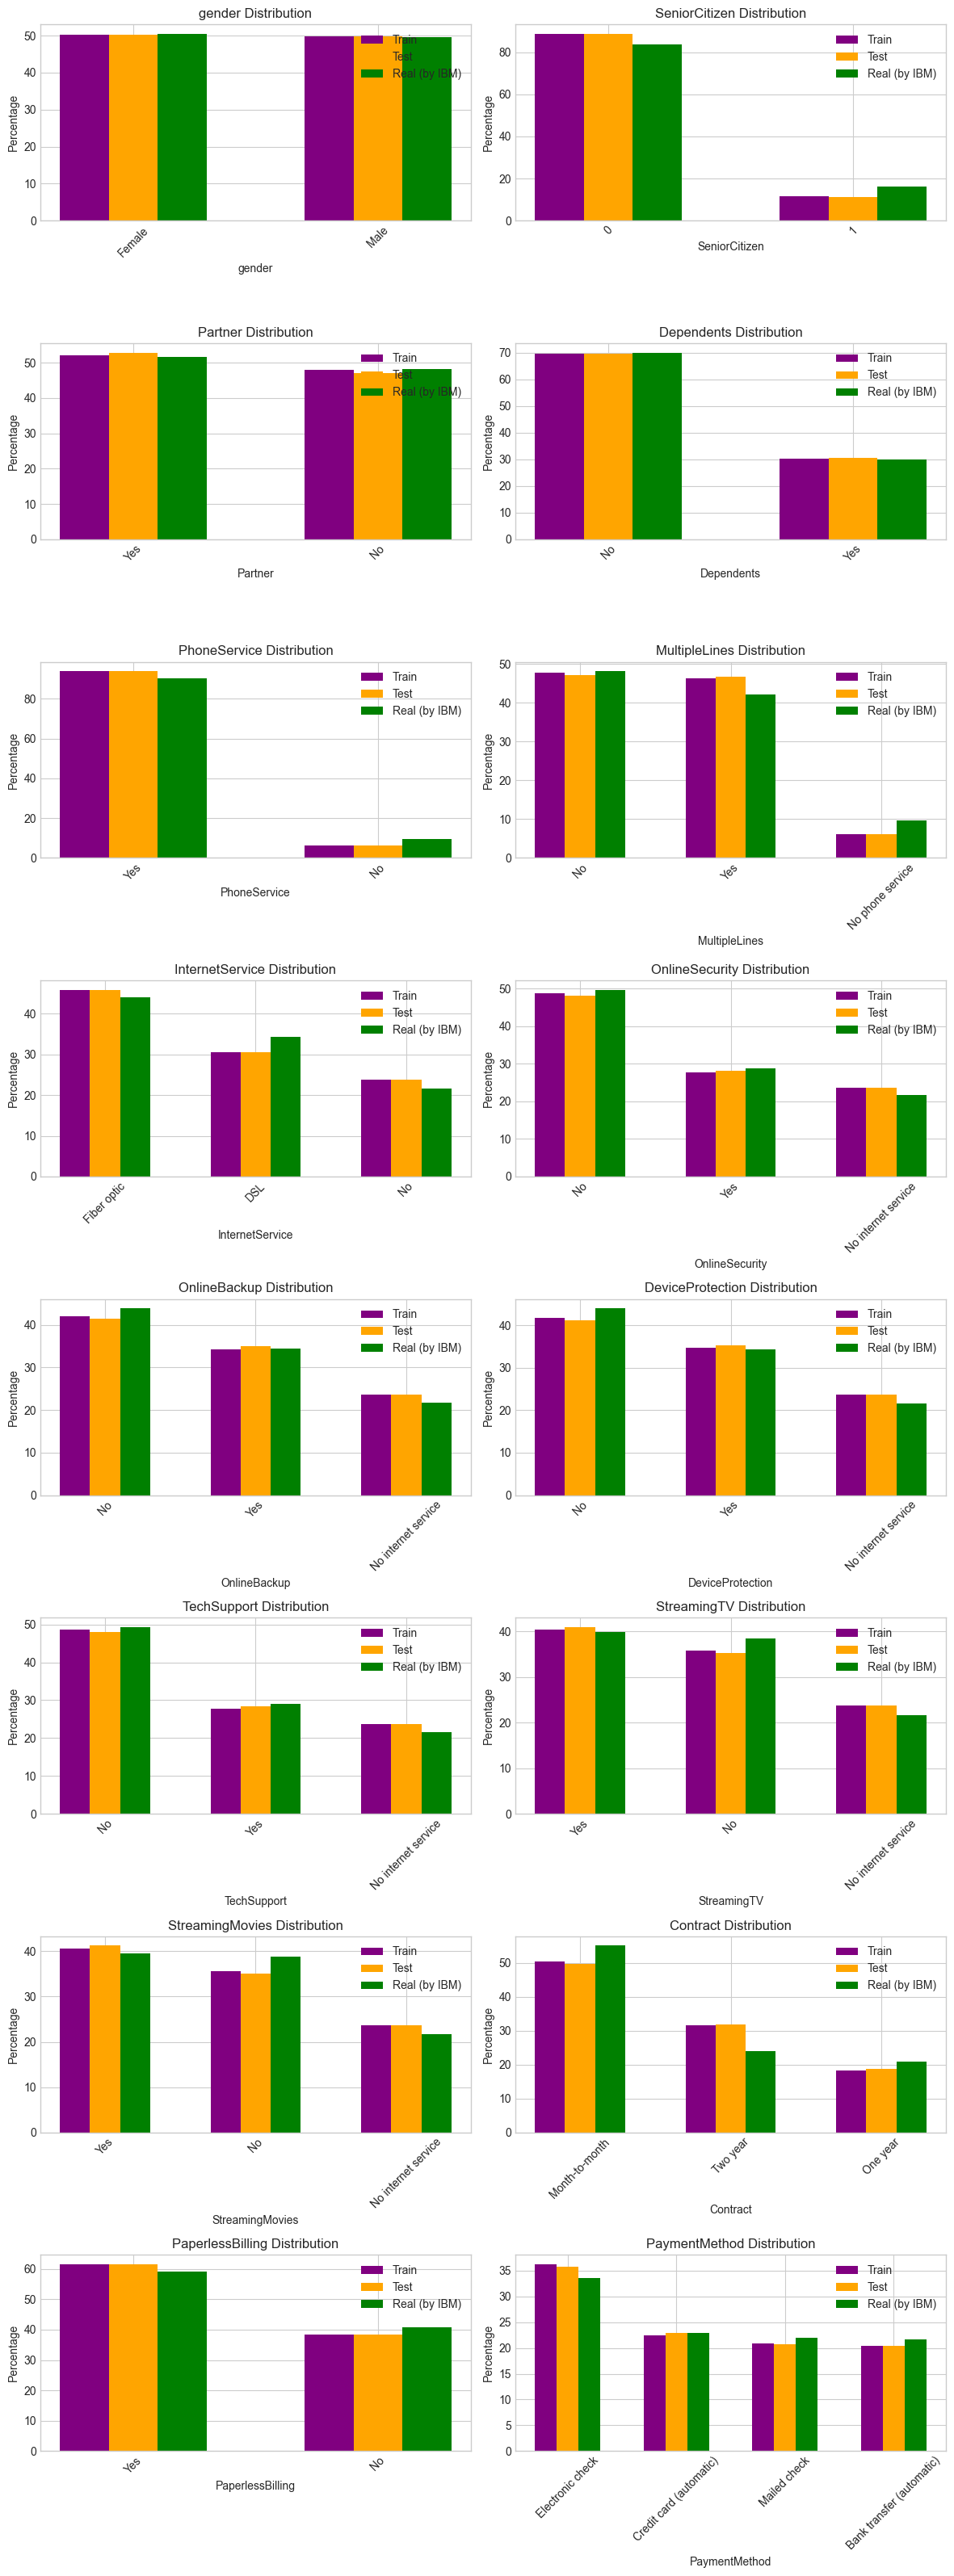

In [184]:
n = len(cat_cols)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):

    train_counts = train[col].value_counts(normalize=True) * 100
    test_counts = test[col].value_counts(normalize=True) * 100
    exog_counts = exog[col].value_counts(normalize=True) * 100

    x = np.arange(len(train_counts.index))
    width = 0.20

    axes[i].bar(x - width, train_counts.values, width, label="Train", color="purple")
    axes[i].bar(x, test_counts.values, width, label="Test", color="orange")
    axes[i].bar(x + width, exog_counts.values, width, label="Real (by IBM)", color="green")
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(train_counts.index.astype(str))
    axes[i].tick_params(axis='x', rotation=45)

    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Percentage")
    axes[i].legend()

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

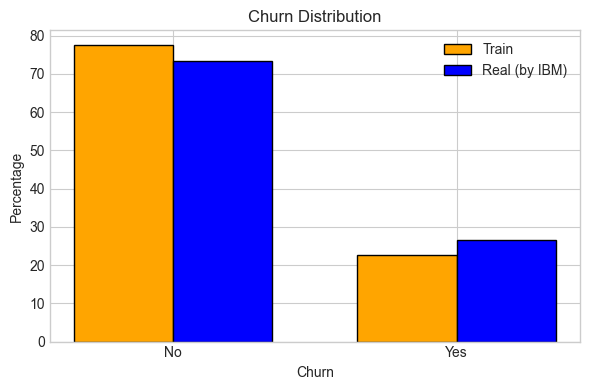

In [185]:
col = "Churn"

train_counts = train[col].value_counts(normalize=True) * 100
exog_counts = exog[col].value_counts(normalize=True) * 100

x = np.arange(len(train_counts.index))
width = 0.35

fig, ax = plt.subplots(figsize=(6,4))

# Train bars
ax.bar(x - width/2, train_counts.values, width,
       label="Train", color="orange", edgecolor="black")

# Exog bars
ax.bar(x + width/2, exog_counts.values, width,
       label="Real (by IBM)", color="blue", edgecolor="black")

ax.set_xticks(x)
ax.set_xticklabels(train_counts.index.astype(str))

ax.set_title(f"{col} Distribution")
ax.set_xlabel(col)
ax.set_ylabel("Percentage")
ax.legend()

plt.tight_layout()
plt.show()

### Kde of train, test and exog

In [186]:
exog.TotalCharges = pd.to_numeric(exog.TotalCharges, errors='coerce')

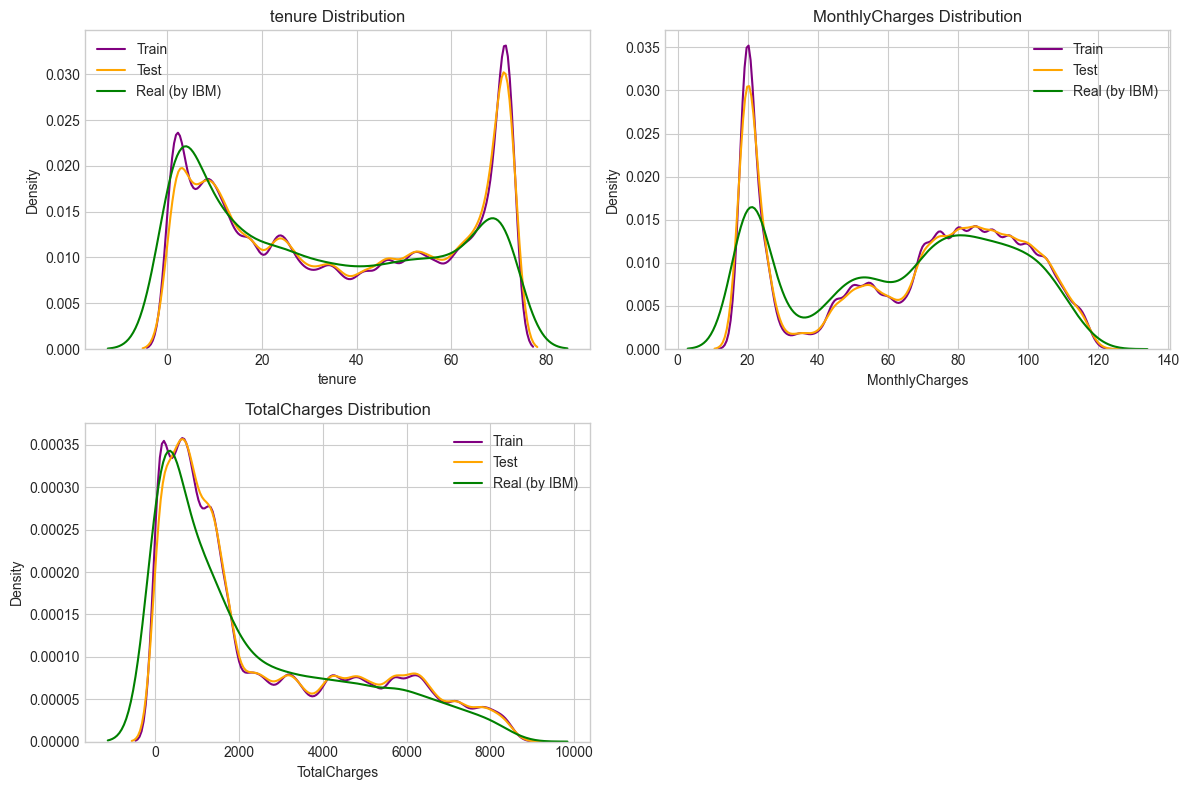

In [187]:
n = len(num_cols)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):

    sns.kdeplot(train[col], ax=axes[i], label="Train", fill=False, color="purple")
    sns.kdeplot(test[col], ax=axes[i], label="Test", fill=False, color="orange")
    sns.kdeplot(exog[col], ax=axes[i], label="Real (by IBM)", fill=False, color="green")

    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")
    axes[i].legend()

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

### Numerical features x target

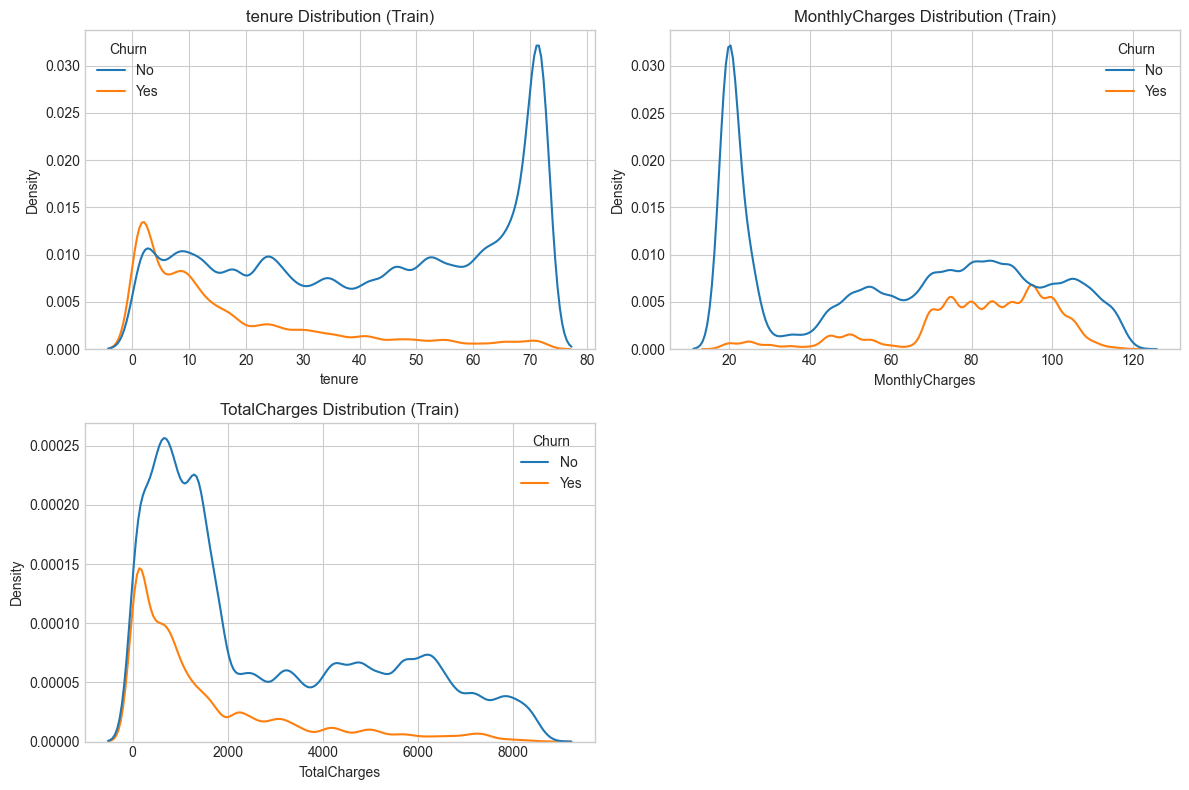

In [188]:
n = len(num_cols)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):

    sns.kdeplot(data=train, x=col, hue="Churn", ax=axes[i], fill=False)
    axes[i].set_title(f"{col} Distribution (Train)")

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

**1. The "Intersection" Advantage (Hard Feature Cut-offs)**

The most valuable parts of these plots are where the orange line (Churn = Yes) crosses or overtakes the blue line (Churn = No). These visual intersections give you exact mathematical thresholds to engineer new binary features.

The MonthlyCharges Danger Zone: Look at the MonthlyCharges plot. The orange line completely dominates the blue line specifically between $70 and $110.

Advantage: Create a boolean feature: is_high_risk_plan = (MonthlyCharges >= 70) & (MonthlyCharges <= 110). This gives the model a direct shortcut to finding churners.

The tenure Flight Risk: The orange line spikes massively and stays above the blue line from 0 to about 10 months, after which it drops off a cliff.

Advantage: Create a feature: is_early_flight_risk = (tenure <= 10).

The Cheap Plan Safe Haven: On the MonthlyCharges plot, there is a massive blue spike around $20 where the orange line is practically flat.

Advantage: Create a feature: is_safe_budget_plan = (MonthlyCharges <= 25).

**2. The Model Selection Advantage (Proof of Non-Linearity)**

If you were considering using Logistic Regression, these plots are telling you to abandon it immediately.

Advantage: Look at how MonthlyCharges goes up, down, up, and down again. It is highly non-linear. Linear models cannot capture this wobbly relationship without massive polynomial transformations. This plot is your visual proof that you must use Tree-based models (XGBoost, LightGBM, CatBoost), which naturally isolate these weirdly shaped clusters.

**3. The Synthetic "Ripples" Advantage**

Zoom in on the orange line for MonthlyCharges between $60 and $100. See those four or five perfectly spaced, artificial-looking "ripples" or bumps? Real human behavior doesn't create perfect ripples like that.

Advantage: Those ripples are a footprint of the synthetic data generator used for this Kaggle competition. Because they exist in the Train data, they will exist in the Test data. If you use a gradient boosting model (like LightGBM) and allow it to build deep enough trees (or use a high max_bin value), it will actually memorize those artificial ripples and score higher on the Kaggle leaderboard than a model that tries to smooth them out.

### Correlation of numerical features x target

In [189]:
train["Churn_num"] = train["Churn"].map({"No": 0, "Yes": 1})

corr = train[num_cols + ["Churn_num"]].corr()["Churn_num"].drop("Churn_num")
corr = corr.sort_values()

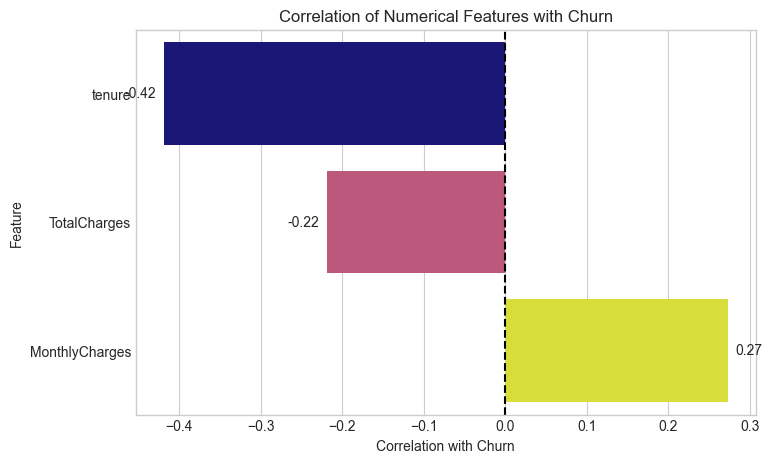

In [190]:
plt.figure(figsize=(8,5))

colors = plt.cm.plasma(np.linspace(0, 1, len(num_cols)))

ax = sns.barplot(
    x=corr.values,
    y=corr.index,
    palette=colors,
)

# Add correlation numbers
for i, v in enumerate(corr.values):
    ax.text(
        v + 0.01 if v >= 0 else v - 0.01,
        i,
        f"{v:.2f}",
        va="center",
        ha="left" if v >= 0 else "right"
    )

plt.title("Correlation of Numerical Features with Churn")
plt.xlabel("Correlation with Churn")
plt.ylabel("Feature")

plt.axvline(0, linestyle="--", color="black")

plt.show()

### Train numerical feature stats vs test numerical feature stats

In [191]:
train_num_stats = train[num_cols].describe().iloc[1:, :].T
train_num_stats

,mean,std,min,25%,50%,75%,max
tenure,36.577258,25.061922,1.00,12.00,35.00,62.0,72.00
MonthlyCharges,65.866223,31.067444,18.25,29.90,74.10,90.8,118.75
TotalCharges,2494.377057,2353.916710,18.80,639.65,1433.65,4263.8,8684.80


In [192]:
test_num_stats = test[num_cols].describe().iloc[1:, :].T
test_num_stats

,mean,std,min,25%,50%,75%,max
tenure,37.279716,24.777625,1.0,13.000,36.00,62.0,72.00
MonthlyCharges,66.130803,31.104139,18.3,30.150,74.35,91.1,118.75
TotalCharges,2544.617351,2348.124379,18.8,677.625,1468.75,4317.3,8684.80


**1. The "No Surprises" Guarantee (Covariate Shift)**

Look at the mean and std (standard deviation) for both tables. They are practically identical.

Train tenure mean: 36.57 | Test tenure mean: 37.27

Train MonthlyCharges std: 31.06 | Test MonthlyCharges std: 31.10

Why it matters: This mathematically confirms that there is zero covariate shift. The test data is just a random sample from the exact same synthetic universe as your training data. This reinforces the rule we established earlier: You can trust your local cross-validation score 100%. If your model works on the train folds, it will work on the test set.

**2. Avoiding "The Extrapolation Trap" (Crucial for Tree Models)**

Look at the min and max columns. This is the most important part of this table.

tenure max: Exactly 72.00 in both.

MonthlyCharges max: Exactly 118.75 in both.

TotalCharges max: Exactly 8684.80 in both.

Why it matters: Tree-based models (like XGBoost, LightGBM, and Random Forests) are notoriously bad at extrapolating. If your training data maxes out at $118.75, and the test data suddenly has a customer paying $200, a tree model won't know what to do and will likely make a bad prediction.

Your Advantage: Because the minimum and maximum boundaries match perfectly, you have absolute confirmation that your tree models will never encounter an "out-of-bounds" value in the test set. They are operating in a perfectly safe, enclosed environment.

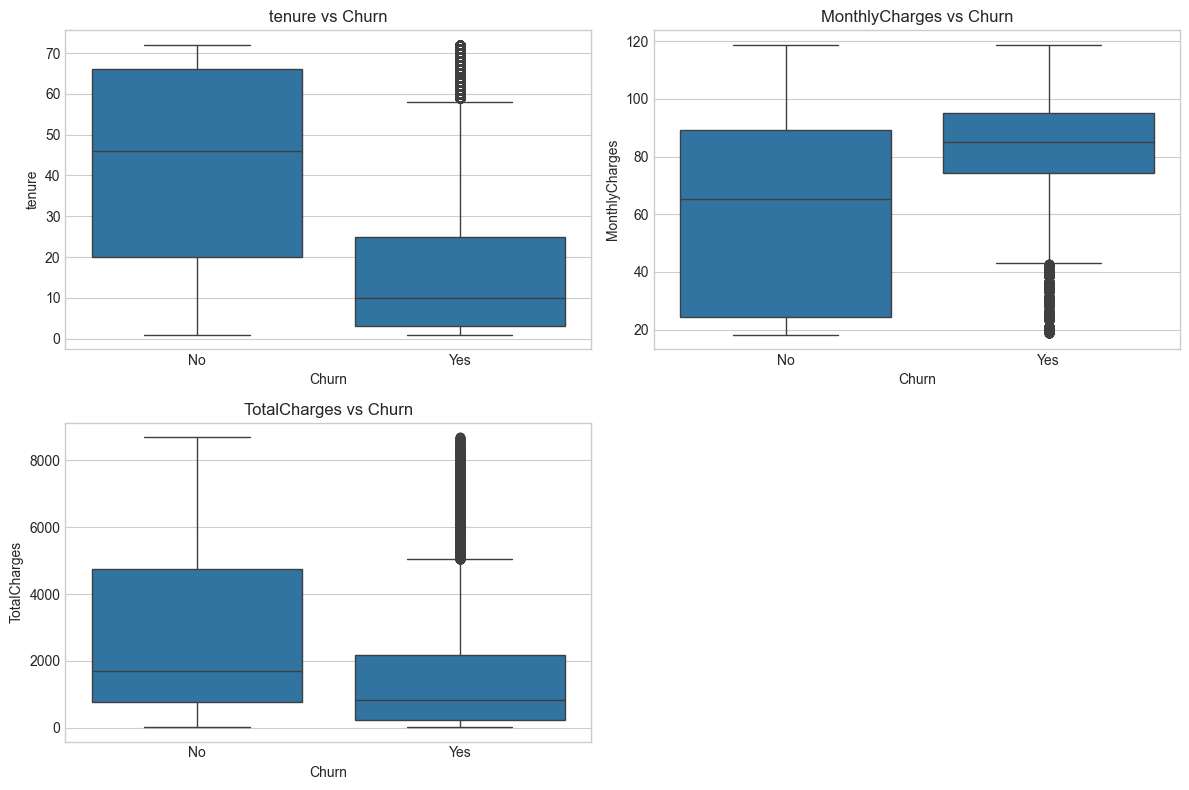

In [193]:
n = len(num_cols)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):

    sns.boxplot(
        data=train,
        x="Churn",
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs Churn")
    axes[i].set_xlabel("Churn")
    axes[i].set_ylabel(col)

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

**1. Exploiting "The Boxes" (The Core Majority)**

The solid colored box represents the Interquartile Range (IQR) — the middle 50% of your customers. The line inside the box is the median.

The Thought Process: You want to find areas where the "box" of the Churners completely separates from the "box" of the Non-Churners.

The Advantage (MonthlyCharges): Look at the MonthlyCharges plot. The bottom of the churner's box (the 25th percentile) is roughly at $70. The median for non-churners is below that. This tells you that the "typical" churning customer pays a premium.

The Action: You can hard-code a feature that mimics this exact box: is_premium_risk = (MonthlyCharges > 70). Tree models will easily make this split themselves, but giving them the exact quartile boundaries speeds up learning.

**2. Exploiting "The Dots" (The Outliers)**

The black dots outside the "whiskers" are statistical outliers. In many traditional statistics classes, they teach you to remove or clip outliers. In Kaggle, do not remove them. These outliers often contain the hidden signals that push you to the top of the leaderboard.

The Thought Process: Who are these people defying the overall trend, and how can I help my model identify them?

The Advantage (tenure): Look at the tenure vs Churn plot. The core box says churners leave early (under 25 months). But look at the thick line of black dots stretching all the way up to 70 months for Churn = Yes! These are "Loyal Churners." They stayed for 5 years and still left. Why? They probably experienced a sudden price hike or a service failure.

The Action: Because tree models split data sequentially, they might group these "Loyal Churners" with the "Safe Loyal" customers and predict them wrong. You need an interaction feature to separate them.

Create a feature that isolates high tenure AND high monthly charges: loyal_but_expensive = (tenure > 60) & (MonthlyCharges > 90). This gives the model a backdoor to find those specific outlier dots.

**3. Exploiting the "Squish" (Extreme Skewness)**

The Thought Process: If a box is completely compressed to the bottom with a massive tail of outliers stretching upward, the data is severely skewed.

The Advantage (TotalCharges): The TotalCharges vs Churn plot shows that for churners, the box is squished near zero, but the outliers shoot up to $8000.

The Action: If you were using a Neural Network or Logistic Regression, this plot is screaming at you to apply a Log Transformation (np.log1p(TotalCharges)). Without it, a linear model's gradients would explode trying to handle those $8000 outliers. If you are using LightGBM or XGBoost, they handle this fine, but it confirms that TotalCharges is mostly noise for churners unless they are an anomaly.

### Why anomalies in churn only??

* 1. The "No Churn" Group Has Massive Variance (Wide Boxes)Look at the blue boxes for Churn = No. They are huge.Because loyal customers come in all shapes and sizes (some brand new, some 6 years old, some paying $20, some paying $110), their data is spread out evenly.This makes the IQR (the box) very tall.Because the box is so tall, the $1.5 \times IQR$ whiskers extend all the way to the absolute minimum and maximum possible limits of the dataset. Statistically, no one in the "No Churn" group is acting weird enough relative to the rest of the group to be considered an outlier.

* 2. The "Churn" Group is Highly Predictable (Squished Boxes)Now look at the Churn = Yes boxes. They are much smaller and compressed to one side.tenure: Almost everyone who churns does so in the first 10–20 months. The box is tightly squished at the bottom. Because the core group is so tightly packed, the mathematical whisker stops around 55 months. Therefore, any customer who churns at 70 months is a massive statistical anomaly compared to other churners.MonthlyCharges: Almost everyone who churns is on an expensive plan (the box is squished at the top, between $75 and $95). Therefore, a customer who churns while on a dirt-cheap $20 plan is mathematically extremely rare, triggering those dots at the bottom.TotalCharges: Since churners usually leave early, they don't rack up high total charges. The box is squished near zero. Someone churning with $8,000 in total charges breaks the mold completely.

# Adversarial Validation

In [194]:
my_train = pd.read_csv(r'C:\Kaggle_Competition\Playground\S6E3-Customer-Churn\data\raw\train.csv')
my_test = pd.read_csv(r'C:\Kaggle_Competition\Playground\S6E3-Customer-Churn\data\raw\test.csv')

In [195]:
my_train = my_train.iloc[:, 1:-1]
my_test = my_test.iloc[:, 1:]

my_train.SeniorCitizen = my_train.SeniorCitizen.map({1: 'Yes', 0: 'No'})
my_test.SeniorCitizen = my_test.SeniorCitizen.map({1: 'Yes', 0: 'No'})

my_train['target'] = 0
my_test['target'] = 1

In [196]:
final_df = pd.concat([my_train, my_test], axis=0, ignore_index=True)

In [197]:
cat_cols = []
for col in final_df.columns:
    if final_df[col].dtype in ['object', 'category']:
        final_df[col] = final_df[col].astype('category')
        cat_cols.append(col)

In [198]:
X_adv = final_df.drop('target', axis=1)
y_adv = final_df['target']

adv_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'max_depth': 5,
    'n_jobs': -1,
    'verbosity': -1,
    'seed': 42
}

# Stratified k fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X_adv))
feature_importances = pd.DataFrame()

for fold, (trn_idx, val_idx) in enumerate(skf.split(X_adv, y_adv), start=1):
    X_trn, y_trn = X_adv.iloc[trn_idx], y_adv.iloc[trn_idx]
    X_val, y_val = X_adv.iloc[val_idx], y_adv.iloc[val_idx]
    
    train_dataset = lgb.Dataset(X_trn, label=y_trn)
    valid_dataset = lgb.Dataset(X_val, label=y_val)
    
    model = lgb.train(
        adv_params,
        train_dataset,
        valid_sets=[train_dataset, valid_dataset],
        num_boost_round=300,
        callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
    )
    
    oof_preds[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    
    fold_importance_df = pd.DataFrame({
        'feature': X_adv.columns,
        'importance': model.feature_importance(importance_type='gain'),
        'fold': fold
    })
    feature_importances = pd.concat([feature_importances, fold_importance_df], axis=0)

# 4. The Verdict
adv_auc = roc_auc_score(y_adv, oof_preds)
print("\n" + "="*50)
print(f"FINAL ADVERSARIAL OOF AUC: {adv_auc:.5f}")
print("="*50)

if adv_auc > 0.60:
    print("\nWARNING: Drift detected! The test data is different from the train data.")
    mean_importance = feature_importances.groupby('feature')['importance'].mean().sort_values(ascending=False).reset_index()
    
    print("\nTop 5 Leaky Features (These are giving away the disguise):")
    print(mean_importance.head(5))
    
    # Plotting the culprits
    plt.figure(figsize=(10, 6))
    sns.barplot(x='importance', y='feature', data=mean_importance.head(15))
    plt.title(f'Top Drift Features (Adv AUC: {adv_auc:.4f})')
    plt.tight_layout()
    plt.show()
else:
    print("\nSUCCESS: Train and Test distributions look identical. Your CV is perfectly safe to trust!")


FINAL ADVERSARIAL OOF AUC: 0.51014

SUCCESS: Train and Test distributions look identical. Your CV is perfectly safe to trust!


In [199]:
for feature in num_cols:
    statistic, p_value = stats.kstest(my_train[feature], my_test[feature])
    
    # If the statistic is relatively large (> 0.1) AND statistically significant (p < 0.05)
    if statistic > 0.1 and p_value < 0.05:
        status = "DRIFT DETECTED"
    elif p_value < 0.05:
        status = "Minor Variance (Usually safe)"
    else:
        status = "Safe (Identical)"
        
    print(f"{feature:<20} | {statistic:<12.4f} | {p_value:<10.4f} | {status}")

tenure               | 0.0171       | 0.0000     | Minor Variance (Usually safe)
MonthlyCharges       | 0.0065       | 0.0000     | Minor Variance (Usually safe)
TotalCharges         | 0.0177       | 0.0000     | Minor Variance (Usually safe)


In [200]:
for feature in cat_cols:

    contingency_table = pd.crosstab(final_df['target'], final_df[feature])
    chi2_stat, p_value, _, _ = stats.chi2_contingency(contingency_table)
    
    train_props = my_train[feature].value_counts(normalize=True)
    test_props = my_test[feature].value_counts(normalize=True)
    
    compare_df = pd.DataFrame({'train': train_props, 'test': test_props}).fillna(0)
    tvd = np.sum(np.abs(compare_df['train'] - compare_df['test'])) / 2
    
    if tvd > 0.05 and p_value < 0.05:
        status = "DRIFT DETECTED"
    elif p_value < 0.05:
        status = "Minor Variance (Safe)"
    else:
        status = "Safe (Identical)"
        
    print(f"{feature:<20} | {tvd:<10.4f} | {p_value:<10.4f} | {status}")

gender               | 0.0004     | 0.7526     | Safe (Identical)
SeniorCitizen        | 0.0005     | 0.5243     | Safe (Identical)
Partner              | 0.0080     | 0.0000     | Minor Variance (Safe)
Dependents           | 0.0022     | 0.0408     | Minor Variance (Safe)
PhoneService         | 0.0003     | 0.6039     | Safe (Identical)
MultipleLines        | 0.0050     | 0.0001     | Minor Variance (Safe)
InternetService      | 0.0000     | 0.9997     | Safe (Identical)
OnlineSecurity       | 0.0054     | 0.0000     | Minor Variance (Safe)
OnlineBackup         | 0.0070     | 0.0000     | Minor Variance (Safe)
DeviceProtection     | 0.0051     | 0.0000     | Minor Variance (Safe)
TechSupport          | 0.0060     | 0.0000     | Minor Variance (Safe)
StreamingTV          | 0.0053     | 0.0000     | Minor Variance (Safe)
StreamingMovies      | 0.0061     | 0.0000     | Minor Variance (Safe)
Contract             | 0.0075     | 0.0000     | Minor Variance (Safe)
PaperlessBilling     | 0.0